English-version

This notebook doesn't use traditional feature engineering; it only performs simple data processing and then uses LSTM in PyTorch for training. If you're looking for ways to wrap sequence data (datasets) and make predictions using PyTorch, I think this notebook will provide you with great inspiration.

I spent 3 days completing this introduction to time series data; if you're doing the same, I recommend you take a look. If you found this helpful, please give it a like 🤪.

中文版本

本笔记本没有传统的特征工程，只是对数据进行了简单的处理，然后使用了 pytorch 中的LSTM 来进行训练。如果你在寻找如何用pytorch进行序列数据包装（dataset）以及如何预测，我想这本笔记本会给你很好的启发。

我用了3天的时间完成了时序数据的入门，如果你也是，我推荐你瞧瞧。如果你觉得对你有所帮助，不妨点个赞🤪.

In [ ]:
import torch

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
import os
import zipfile
from tqdm import tqdm
import warnings

warnings.filterwarnings("ignore")

In [ ]:
torch.cuda.is_available()
torch.__version__

'2.6.0+cu124'

In [ ]:
# 解压缩
zip_path=r"data.zip"
with zipfile.ZipFile(zip_path,"r") as file:
    file.extractall()
print("zip解压完成")

<center><h2>Basic data processing</h2></center>

In [3]:
train=pd.read_csv("./data/train.csv",parse_dates=["date"])
test=pd.read_csv("./data/test.csv",parse_dates=["date"])
sub=pd.read_csv("./data/sample_submission.csv")
oil=pd.read_csv("./data/oil.csv",parse_dates=["date"])

print("train shape:",train.shape)
display(train.head())

print("\ntest shape:",test.shape)
display(test.head())

print("\noil shape:",oil.shape)
display(oil.head())

train shape: (3000888, 6)


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0



test shape: (28512, 5)


,id,date,store_nbr,family,onpromotion
0,3000888,2017-08-16,1,AUTOMOTIVE,0
1,3000889,2017-08-16,1,BABY CARE,0
2,3000890,2017-08-16,1,BEAUTY,2
3,3000891,2017-08-16,1,BEVERAGES,20
4,3000892,2017-08-16,1,BOOKS,0



oil shape: (1218, 2)


,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


In [4]:
# 查看各个数据的基本信息
print("train info:")
train.info()

print("\n\ntest info:")
test.info()

print("\n\noil info:")
oil.info()


train info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 137.4+ MB


test info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28512 entries, 0 to 28511
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id           28512 non-null  int64         
 1   date         28512 non-null  datetime64[ns]
 2   store_nbr    28512 non-null  int64         
 3   family       28512 non-null  object        
 4   onpromotion  28512 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 1.1+

In [5]:
def dispaly_missing_data(df):
    CATS,NUM=[],[]
    for col in df.columns:
        if df[col].dtype=="object":
            CATS.append(col)
            print(f"{col:15}[CAT]{df[col].nunique():-20}unique{df[col].isna().sum():10}NAN")
        else:
            NUM.append(col)
            print(f"{col:15}[NUM]{df[col].nunique():-20}unique{df[col].isna().sum():10}NAN")

    print("CATS:",CATS)
    print("NUM:",NUM)  
    return CATS,NUM 


In [6]:
print("\ntrain")
dispaly_missing_data(train)

print("\ntest")
dispaly_missing_data(test)

print("\noil")
dispaly_missing_data(oil)


train
id             [NUM]             3000888unique         0NAN
date           [NUM]                1684unique         0NAN
store_nbr      [NUM]                  54unique         0NAN
family         [CAT]                  33unique         0NAN
sales          [NUM]              379610unique         0NAN
onpromotion    [NUM]                 362unique         0NAN
CATS: ['family']
NUM: ['id', 'date', 'store_nbr', 'sales', 'onpromotion']

test
id             [NUM]               28512unique         0NAN
date           [NUM]                  16unique         0NAN
store_nbr      [NUM]                  54unique         0NAN
family         [CAT]                  33unique         0NAN
onpromotion    [NUM]                 212unique         0NAN
CATS: ['family']
NUM: ['id', 'date', 'store_nbr', 'onpromotion']

oil
date           [NUM]                1218unique         0NAN
dcoilwtico     [NUM]                 998unique        43NAN
CATS: []
NUM: ['date', 'dcoilwtico']


([], ['date', 'dcoilwtico'])

<Axes: title={'center': 'Oil Price'}, xlabel='date', ylabel='dcoilwtico'>

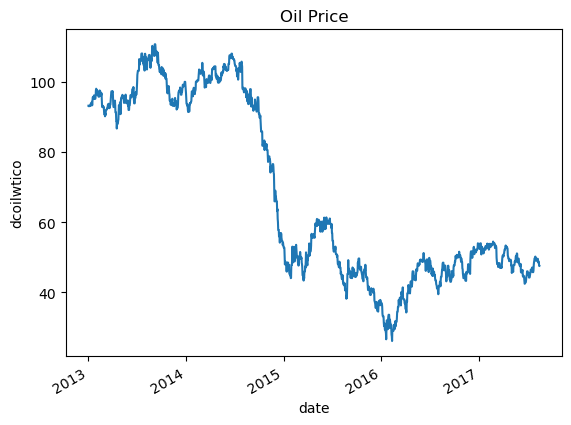

In [7]:
oil_price=oil.set_index("date")["dcoilwtico"].interpolate()
oil_price=oil_price.reindex(pd.to_datetime(train["date"]).unique()).ffill().bfill()
oil_price.plot(title="Oil Price",ylabel="dcoilwtico",xlabel="date")

Different stores use different predictive logic for different products.   "item_ID" is used to distinguish

In [8]:
from sklearn.preprocessing import LabelEncoder
train["item_ID"]=train["store_nbr"].astype(str)+"_"+train["family"]
test["item_ID"]=test["store_nbr"].astype(str)+"_"+test["family"]
pre=LabelEncoder()
train["item_enc"]=pre.fit_transform(train["item_ID"])
test["item_enc"]=pre.transform(test["item_ID"])

pre=LabelEncoder()
train["family"]=pre.fit_transform(train["family"])
test["family"]=pre.transform(test["family"])

print(f"Created {train['item_enc'].nunique()} features")

Created 1782 features


In [9]:
def create_time_features(df):
    df=df.copy()
    df["day_of_week"]=df["date"].dt.dayofweek+1
    df["month"]=df["date"].dt.month
    df["day"]=df["date"].dt.day
    df=df.merge(oil_price.reset_index(),on="date",how="left")
    df["is_weekend"]=df["day_of_week"].isin([6,7]).astype(int)
    df["promotion"]=df["onpromotion"].astype(int)
    
    return df

train=create_time_features(train)
test=create_time_features(test)

In [10]:
train.head()

,id,date,store_nbr,family,sales,onpromotion,item_ID,item_enc,day_of_week,month,day,dcoilwtico,is_weekend,promotion
0,0,2013-01-01,1,0,0.0,0,1_AUTOMOTIVE,330,2,1,1,93.14,0,0
1,1,2013-01-01,1,1,0.0,0,1_BABY CARE,331,2,1,1,93.14,0,0
2,2,2013-01-01,1,2,0.0,0,1_BEAUTY,332,2,1,1,93.14,0,0
3,3,2013-01-01,1,3,0.0,0,1_BEVERAGES,333,2,1,1,93.14,0,0
4,4,2013-01-01,1,4,0.0,0,1_BOOKS,334,2,1,1,93.14,0,0


In [11]:
#Here, we retain the feature `family`, 
# even though `item_id` already includes `family`; I just thought it might be useful.

train=train.drop(columns=["id","item_ID"])
test=test.drop(columns=["id","item_ID"])

train.head()

,date,store_nbr,family,sales,onpromotion,item_enc,day_of_week,month,day,dcoilwtico,is_weekend,promotion
0,2013-01-01,1,0,0.0,0,330,2,1,1,93.14,0,0
1,2013-01-01,1,1,0.0,0,331,2,1,1,93.14,0,0
2,2013-01-01,1,2,0.0,0,332,2,1,1,93.14,0,0
3,2013-01-01,1,3,0.0,0,333,2,1,1,93.14,0,0
4,2013-01-01,1,4,0.0,0,334,2,1,1,93.14,0,0


In [12]:
# 从下表可以看出，每一类别训练数据有1684个时间步，测试数据侧有16个时间步（这也是我们需要预测的）
# 在这里，我们取 train_step=90,test_step=16

# As shown in the table below, each category of training data has 1684 time steps, and the test data has 16 time steps (which is what we need to predict).
# Here, we set train_step=90, test_step=16

train.groupby(["item_enc"])["date"].size().reset_index(), test.groupby(["item_enc"])["date"].size().reset_index()

(      item_enc  date
 0            0  1684
 1            1  1684
 2            2  1684
 3            3  1684
 4            4  1684
 ...        ...   ...
 1777      1777  1684
 1778      1778  1684
 1779      1779  1684
 1780      1780  1684
 1781      1781  1684
 
 [1782 rows x 2 columns],
       item_enc  date
 0            0    16
 1            1    16
 2            2    16
 3            3    16
 4            4    16
 ...        ...   ...
 1777      1777    16
 1778      1778    16
 1779      1779    16
 1780      1780    16
 1781      1781    16
 
 [1782 rows x 2 columns])

In [13]:
print("\ntrain")
dispaly_missing_data(train)

print("\ntest")
dispaly_missing_data(test)


train
date           [NUM]                1684unique         0NAN
store_nbr      [NUM]                  54unique         0NAN
family         [NUM]                  33unique         0NAN
sales          [NUM]              379610unique         0NAN
onpromotion    [NUM]                 362unique         0NAN
item_enc       [NUM]                1782unique         0NAN
day_of_week    [NUM]                   7unique         0NAN
month          [NUM]                  12unique         0NAN
day            [NUM]                  31unique         0NAN
dcoilwtico     [NUM]                1029unique         0NAN
is_weekend     [NUM]                   2unique         0NAN
promotion      [NUM]                 362unique         0NAN
CATS: []
NUM: ['date', 'store_nbr', 'family', 'sales', 'onpromotion', 'item_enc', 'day_of_week', 'month', 'day', 'dcoilwtico', 'is_weekend', 'promotion']

test
date           [NUM]                  16unique         0NAN
store_nbr      [NUM]                  54unique       

([],
 ['date',
  'store_nbr',
  'family',
  'onpromotion',
  'item_enc',
  'day_of_week',
  'month',
  'day',
  'dcoilwtico',
  'is_weekend',
  'promotion'])

In [14]:
import random

CAT,NUM=["item_enc"],["family","store_nbr","day_of_week","dcoilwtico","month","day","is_weekend","promotion"]

class SalesDataset(Dataset):
    def __init__(self,df,enc_len=140,pred_len=16,windows=100,val_size=0.2,mode="train"):
        self.mode=mode
        self.enc_len=enc_len
        self.pred_len=pred_len
        self.windows=windows if mode=="train" else 1

        df=df.sort_values(["item_enc","date"]).reset_index(drop=True)
        self.data=[]
        for _,group in df.groupby("item_enc"):
            num=group[NUM].values.astype(np.float32)
            cat=group[CAT].values.astype(np.int64)
            sales=group["sales"].values.astype(np.float32)

            L=len(sales)
            # 最大合法窗口起始点
            # Maximum legal window start point
            max_start=L-enc_len-pred_len
            if mode =="train" or mode=="val":
                # 只取最近的窗口
                # Take only the nearest window
                starts=range(max(0,max_start-windows+1),max_start+1)
            elif mode=="test":
                starts=[L-enc_len]
            else:
                raise NameError
            for start in starts:
                y=sales[start+enc_len:start+enc_len+pred_len]
                self.data.append({
                    "num":num[start:start+enc_len],
                    "cat":cat[start:start+enc_len],
                    "y":y if len(y) else np.ones(pred_len), 
                    # temp=[1,2,3,4]  temp[4:4+16]=[]
                })
        # self.data是固定的
        # self.data is fixed.
        if mode=="train" :
            random.seed(42)
            random.shuffle(self.data)
            self.data=self.data[int(len(self.data)*val_size):]
        elif mode=="val":
            random.seed(42)
            random.shuffle(self.data)
            self.data=self.data[:int(len(self.data)*val_size)]
            
    def __len__(self):
        return len(self.data)

    def __getitem__(self,idx):
        # 继承自torch的 Dataset ,其强制要求每次传入一个idx，最后进行堆叠
        # Dataset, inherited from torch, requires that one idx be passed in each time, and then the results are stacked.
        item=self.data[idx]
        return {
            "encoder_num":torch.tensor(item["num"],dtype=torch.float32),
            "encoder_cat":torch.tensor(item["cat"],dtype=torch.long),
            "y":torch.tensor(item["y"],dtype=torch.float32)
        }

In [15]:
configue={
    "batch_size":128,
    "epochs":20,
    "device":"cuda" if torch.cuda.is_available() else "cpu"
}

In [16]:
class logloss(nn.MSELoss):
    def __init__(self,eps=1e-6,**kwargs):
        super().__init__(**kwargs)
        self.eps=eps
    def forward(self,y,pred):
        pred=torch.clamp(pred,min=0)
        y,pred=torch.log1p(y),torch.log1p(pred)

        return torch.sqrt(torch.mean((y-pred)**2))

In [17]:
class Accumulator:
    def __init__(self,num):
        self.metric=[0]*num
    def __getitem__(self,idx):
        return self.metric[idx]
    def add(self,*args):
        if args:
            for i,arg in enumerate(args):
                self.metric[i]+=arg

class Recorder:
    def __init__(self,num):
        self.metric=[[] for _ in range(num)]
    def __getitem__(self,idx):
        return self.metric[idx]
    def __len__(self):
        return len(self.metric)
    def add(self,*args):
        if args:
            for i,arg in enumerate(args):
                self.metric[i].append(arg)

In [18]:
class LSTM(nn.Module):
    def __init__(self,num_features=len(NUM),embed_dim=16,hidden_size=128,num_layers=2,dropout=0.2):
        super().__init__()

        #压缩序列标签
        self.embed_series=nn.Embedding(1782,embed_dim)
        # 数据特征投影
        self.num_features=nn.Linear(num_features,hidden_size)

        # LSTM
        self.LSTM=nn.LSTM(input_size=hidden_size+embed_dim,
                         hidden_size=hidden_size,
                         num_layers=num_layers,
                         batch_first=True)
        self.dropout=nn.Dropout(dropout)
        self.head=nn.Sequential(
            nn.Linear(hidden_size,64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(64,16),
        )

    def forward(self,encoder_num,encoder_cat):
        """
        encoder_num shape :(batch,90,len(NUM))
        encoder_cat shape :(batch,90,1)
        """
        encoder_num=self.num_features(encoder_num)
        encoder_cat=self.embed_series(encoder_cat.squeeze(-1))
        x=torch.cat([encoder_cat,encoder_num],dim=-1)

        out,_=self.LSTM(x)
        out=self.dropout(out)
        pred=self.head(out[:,-1,:])

        # out shape :(batch,16)
        return pred

In [19]:
@torch.no_grad
def predict(net,data_iter,device,criterion):
    net.eval()
    net=net.to(device)
    metric=Accumulator(2)
    record=Recorder(1)
    for batch in data_iter:
        pred=net(batch["encoder_num"].to(device),batch["encoder_cat"].to(device))
        loss=criterion(batch["y"].to(device),pred)
        metric.add(loss.cpu().item()*len(pred),len(pred))
        record.add(pred.cpu())
    loss=metric[0]/metric[1]
    pred=torch.cat(record[0],dim=0)
    net.train()
    # return (loss,pred)
    return loss, pred

In [20]:
train_iter=DataLoader(SalesDataset(train,mode="train"),batch_size=configue["batch_size"],shuffle=True)
test_iter=DataLoader(SalesDataset(train,mode="test"),batch_size=configue["batch_size"],shuffle=False)
val_iter=DataLoader(SalesDataset(train,mode="val"),batch_size=configue["batch_size"],shuffle=False)

device=configue["device"]
net=LSTM(embed_dim=32,num_layers=4).to(device)
optim=torch.optim.AdamW(net.parameters(),lr=1e-3,weight_decay=1e-4)
scheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(mode="min",optimizer=optim,patience=2,factor=0.3)
criterion=logloss()
# <training>
pbar=tqdm(total=configue['epochs'],desc="<training>")
epoch_metric=Recorder(2)

print("training...")
for epoch in range(configue["epochs"]):
    batch_metric=Accumulator(2)
    for x in train_iter:
        y_true=x["y"].to(device)
        optim.zero_grad()
        y_pred=net(x["encoder_num"].to(device),x["encoder_cat"].to(device))
        loss=criterion(y_true,y_pred)
        loss.backward()
        optim.step()

        batch_metric.add(loss.cpu().item()*len(y_true),len(y_true))
    # predicting
    val_loss,_=predict(net,val_iter,device,criterion)
    scheduler.step(val_loss)
    
    pbar.update(1)
    pbar.set_description(f"<train loss>{batch_metric[0]/batch_metric[1]}     <val loss>{val_loss}")
    epoch_metric.add(batch_metric[0]/batch_metric[1],val_loss)
pbar.close()

<training>:   0%|          | 0/20 [00:00<?, ?it/s]

training...


<train loss>0.850151779301105     <val loss>0.7331627575904298:  15%|█▌        | 3/20 [01:28<08:18, 29.31s/it] 

KeyboardInterrupt: 

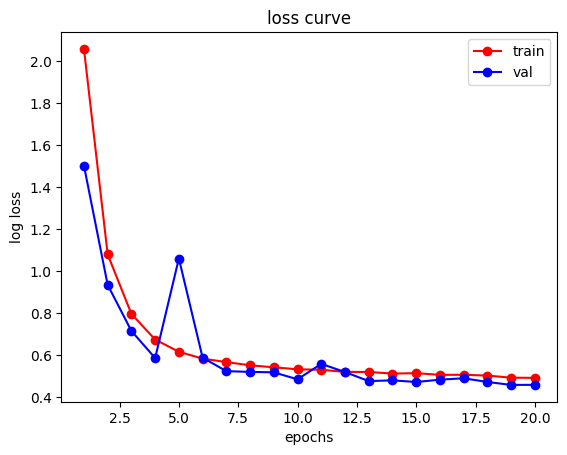

In [ ]:
plt.plot(range(1,len(epoch_metric[0])+1),epoch_metric[0],"r-o",label="train")
plt.plot(range(1,len(epoch_metric[1])+1),epoch_metric[1],"b-o",label="val")
plt.title("loss curve")
plt.xlabel("epochs")
plt.ylabel("log loss")
plt.legend()
plt.savefig("LSTM'loss curve")
plt.show()

In [ ]:
test_iter=DataLoader(SalesDataset(train,mode="test"),batch_size=configue["batch_size"],shuffle=False)

print("predicting ...")
_,pred=predict(net,test_iter,device,criterion)
print(pred.shape)

predicting ...
torch.Size([1782, 16])


In [ ]:
# 反演
test_temp=test.sort_values(["item_enc","date"])
index=test_temp.index

sub_temp=sub.iloc[index]
sub_temp["sales"]=pred.flatten().tolist()
sub_temp=sub_temp.sort_index()    # 默认按行索引排序
sub_temp.to_csv("submission_v1.csv",index=False)